# Базовый сегментационный блокнот — только раны

**Цель:** Создать воспроизводимый базовый вариант Mask R-CNN для сегментации
только ран. Один целевой класс: `wound` (+ фон).

**Набор данных:** `data/wound_focus_clean/` с готовыми разбиениями train / val / test.

**Результаты:** чекпоинты, кривые обучения, метрики COCO, качественные предсказания,
отчёты — в каталоге `experiments/maskrcnn/`.


## 1: Настройка / Импорты / Конфигурация


In [1]:
%matplotlib inline

import json
import sys
import time
import platform
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

SCRIPT_DIR = Path.cwd().resolve()
PROJECT_ROOT = SCRIPT_DIR.parent.parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if (SCRIPTS_DIR / "augmentation_strategy.py").exists():
    sys.path.insert(0, str(SCRIPTS_DIR))
sys.path.insert(0, str(SCRIPT_DIR))

from pipeline_utils import (
    set_seed,
    get_device,
    create_dataset,
    make_dataloaders,
    WOUND_ONLY_CLASSES,
)
from train_model import (
    build_model,
    train_one_epoch,
    validate_one_epoch,
    evaluate_metrics,
    save_best_checkpoint,
    save_last_checkpoint,
    load_checkpoint,
    validate_dataset_labels,
    predict_single_image,
    predict_image,
    visualize_prediction,
    calculate_wound_area,
    save_qualitative_predictions,
    save_training_curves,
    save_ap_curves,
    generate_wound_only_report,
    validate_wound_dataset,
    MEAN as IMG_MEAN,
    STD as IMG_STD,
)
try:
    from train_model import display_results_curves, display_results_predictions
except ImportError:
    def display_results_curves(results_dir, max_show=2):
        pass  # Пустая функция, если недоступно
    def display_results_predictions(results_dir, n_show=8):
        pass  # Пустая функция, если недоступно

print("=" * 60)
print("Библиотеки успешно загружены")
print("=" * 60)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
print("=" * 60)

# ---------------------------------------------------------------------------
# Конфигурация только ран (соответствует train_model.py)
# ---------------------------------------------------------------------------
CONFIG = {
    "data_root": str(PROJECT_ROOT / "data" / "wound_focus_clean"),
    "ann_file_train": str(PROJECT_ROOT / "data" / "wound_focus_clean" / "train_wound_only.json"),
    "ann_file_val": str(PROJECT_ROOT / "data" / "wound_focus_clean" / "val_wound_only.json"),
    "ann_file_test": str(PROJECT_ROOT / "data" / "wound_focus_clean" / "test_wound_only.json"),
    "output_dir": str(SCRIPT_DIR / "checkpoints"),
    "results_dir": str(SCRIPT_DIR / "results"),
    "reports_dir": str(SCRIPT_DIR / "reports"),
    "seed": 42,
    "batch_size": 2,
    "num_workers": 0 if platform.system() == "Windows" else 4,
    "epochs": 50,
    "lr": 0.001,
    "image_size": (512, 512),
    "early_stop_patience": 12,
    "early_stop_min_delta": 0.003,
    "loss_clip_max": 100.0,
    "loss_skip_threshold": 1000.0,
    "skip_invalid_targets": True,
    "device_prefer_cuda": True,
    "use_medical_augmentation": True,
    "preserve_marker": True,
    "intensity": "moderate",
    "num_qualitative_samples": 8,
    "conf_thresh_qualitative": 0.5,
    "pixels_per_cm": 26.0,  # Площадь раны в см² (~20см поле зрения при 512×512)
}

print("\nКонфигурация:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Библиотеки успешно загружены
PyTorch: 2.5.1+cu121
CUDA:    True
GPU:     NVIDIA GeForce RTX 4060 Laptop GPU

Конфигурация:
  data_root: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean
  ann_file_train: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\train_wound_only.json
  ann_file_val: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\val_wound_only.json
  ann_file_test: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\test_wound_only.json
  output_dir: E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\checkpoints
  results_dir: E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\results
  reports_dir: E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\reports
  seed: 42
  batch_size: 2
  num_workers: 0
  epochs: 50
  lr: 0.001
  image_size: (512, 512)
  early_stop_patience: 12
  early_stop_min_delta: 0.003
  loss_clip_max: 100.0
  loss_skip_threshold: 1000.0
  skip_invalid_targets: Tr

## 2: Проверка и загрузка набора данных


In [2]:
# ============================================================================
# 2.1 Проверка набора данных перед обучением (train_model.validate_wound_dataset)
# ============================================================================

print("Запуск проверки набора данных перед обучением...")
validation_result = validate_wound_dataset()
if validation_result != 0:
    raise RuntimeError("Проверка набора данных не пройдена — исправьте данные перед обучением.")
print()

# ============================================================================
# 2.2 Создание наборов данных и загрузчиков
# ============================================================================

set_seed(CONFIG["seed"])
device = get_device(CONFIG.get("device_prefer_cuda", True))
print(f"Устройство: {device}")
if device.type == "cuda":
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
print()

data_root = Path(CONFIG["data_root"])
train_ann = Path(CONFIG["ann_file_train"])
val_ann = Path(CONFIG["ann_file_val"])
test_ann = Path(CONFIG["ann_file_test"])
output_dir = Path(CONFIG["output_dir"])
results_dir = Path(CONFIG["results_dir"])
reports_dir = Path(CONFIG["reports_dir"])

output_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

print("Загрузка наборов данных...")
train_dataset = create_dataset(
    root=str(data_root),
    annotation_file=str(train_ann),
    train=True,
    image_size=CONFIG["image_size"],
    use_medical_augmentation=CONFIG["use_medical_augmentation"],
    preserve_marker=CONFIG["preserve_marker"],
    intensity=CONFIG["intensity"],
    target_classes=WOUND_ONLY_CLASSES,
)
val_dataset = create_dataset(
    root=str(data_root),
    annotation_file=str(val_ann),
    train=False,
    image_size=CONFIG["image_size"],
    use_medical_augmentation=False,
    preserve_marker=CONFIG["preserve_marker"],
    intensity=CONFIG["intensity"],
    target_classes=WOUND_ONLY_CLASSES,
)
test_dataset = create_dataset(
    root=str(data_root),
    annotation_file=str(test_ann),
    train=False,
    image_size=CONFIG["image_size"],
    use_medical_augmentation=False,
    preserve_marker=CONFIG["preserve_marker"],
    intensity=CONFIG["intensity"],
    target_classes=WOUND_ONLY_CLASSES,
)

train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)
print(f"  Train: {train_size}  |  Val: {val_size}  |  Test: {test_size}")
print()

train_loader, val_loader = make_dataloaders(
    train_dataset,
    val_dataset,
    batch_size=CONFIG["batch_size"],
    num_workers=CONFIG["num_workers"],
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    collate_fn=lambda b: tuple(zip(*b)),
    pin_memory=torch.cuda.is_available(),
)
print("Наборы данных и загрузчики готовы.")


Запуск проверки набора данных перед обучением...
Wound-Only Dataset Validation
Data root: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean

--- train ---
  [OK] train: categories = [{'id': 1, 'name': 'wound'}]
  [OK] train: all 257 images found
  [OK] train: all 373 annotations valid
  [OK] train: 257 images (matches expected)

--- val ---
  [OK] val: categories = [{'id': 1, 'name': 'wound'}]
  [OK] val: all 57 images found
  [OK] val: all 85 annotations valid
  [OK] val: 57 images (matches expected)

--- test ---
  [OK] test: categories = [{'id': 1, 'name': 'wound'}]
  [OK] test: all 55 images found
  [OK] test: all 74 annotations valid
  [OK] test: 55 images (matches expected)

--- Dataset sample (WoundDataset) ---
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Filtering classes. Keeping only: ['wound']
  - Class 'wound' (ID 1) mapped to New ID 1
Total classes for training: 2 (including background)
  [OK] Sampled 5 images; masks non

## 3: Визуализация примеров и инициализация модели


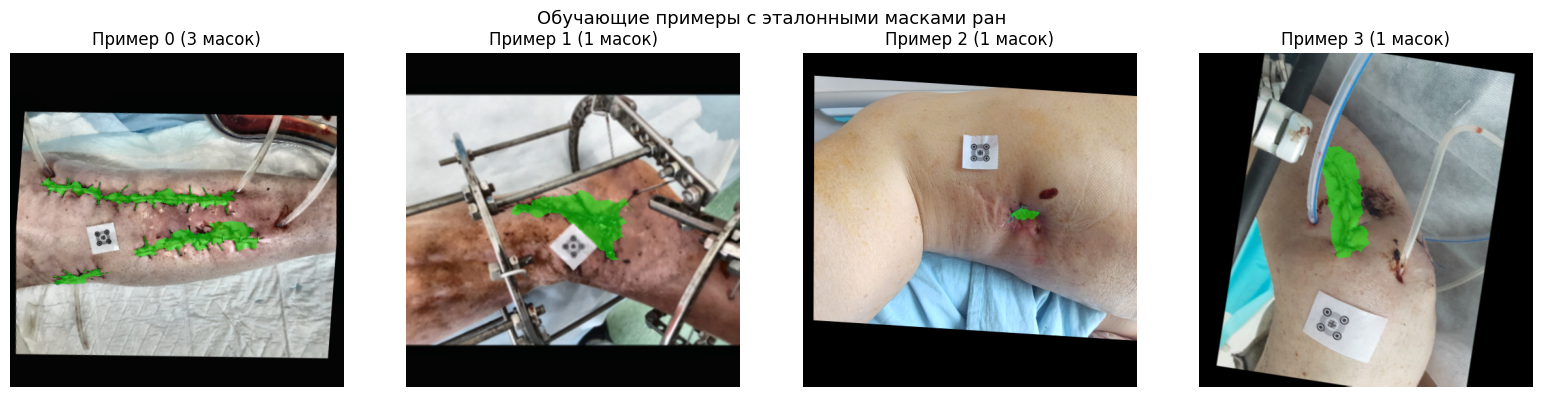

Модель num_classes: 2

--- Проверка меток при запуске ---
  Уникальные метки в батчах: [1]
---------------------------

Оптимизатор: SGD  lr=0.001
Планировщик: StepLR  step_size=5  gamma=0.1


In [3]:
# ============================================================================
# 3.1 Визуализация обучающих примеров с эталонными масками
# ============================================================================

NUM_VIS = 4
fig, axes = plt.subplots(1, NUM_VIS, figsize=(4 * NUM_VIS, 4))
if NUM_VIS == 1:
    axes = [axes]

for idx in range(min(NUM_VIS, len(train_dataset))):
    img_tensor, target = train_dataset[idx]
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * IMG_STD + IMG_MEAN
    img_np = np.clip(img_np, 0, 1)

    masks = target.get("masks")
    if masks is not None and masks.numel() > 0:
        combined = masks.sum(dim=0).clamp(0, 1).cpu().numpy()
        overlay = img_np.copy()
        overlay[combined > 0.5] = overlay[combined > 0.5] * 0.5 + np.array([0, 1, 0]) * 0.5
        img_np = overlay

    axes[idx].imshow(img_np)
    n_masks = masks.shape[0] if masks is not None else 0
    axes[idx].set_title(f"Пример {idx} ({n_masks} масок)")
    axes[idx].axis("off")

fig.suptitle("Обучающие примеры с эталонными масками ран", fontsize=13)
fig.tight_layout()
plt.show()

# ============================================================================
# 3.2 Построение модели (фон + рана = 2 класса)
# ============================================================================

base_ds = train_dataset.dataset if isinstance(train_dataset, torch.utils.data.Subset) else train_dataset
num_classes = base_ds.num_classes
print(f"Модель num_classes: {num_classes}")
model = build_model(num_classes=num_classes, pretrained_backbone=True)
model.to(device)

print("\n--- Проверка меток при запуске ---")
unique_labels = validate_dataset_labels(train_loader, num_classes, num_batches=5)
print(f"  Уникальные метки в батчах: {unique_labels}")
print("---------------------------\n")

# ============================================================================
# 3.3 Оптимизатор и планировщик
# ============================================================================

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["lr"],
    momentum=0.9,
    weight_decay=0.0005,
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
class_mapping = getattr(base_ds, "class_mapping", {})

print(f"Оптимизатор: SGD  lr={CONFIG['lr']}")
print(f"Планировщик: StepLR  step_size=5  gamma=0.1")


## 4: Цикл обучения / Валидация / Чекпоинты


In [4]:
# ============================================================================
# 4.1 Цикл обучения (из train_model.py)
# ============================================================================

results = {
    "train_losses": [],
    "val_losses": [],
    "metrics_per_epoch": [],
    "best_metric": 0.0,
    "best_epoch": 0,
    "best_bbox_AP50": 0.0,
    "best_segm_AP50": 0.0,
    "training_start": datetime.now().isoformat(),
    "training_end": None,
    "training_time": 0.0,
    "config": CONFIG,
    "num_classes": num_classes,
    "train_size": train_size,
    "val_size": val_size,
    "test_size": test_size,
    "device": str(device),
    "issues_found": "None noted.",
    "unresolved_issues": "None.",
}

best_combined_AP50 = 0.0
best_epoch = 0
early_stop_patience = CONFIG.get("early_stop_patience", 12)
epochs_without_improve = 0

print("=" * 60)
print("Начало обучения")
print("=" * 60)
start_time = time.time()

try:
    for epoch in range(CONFIG["epochs"]):
        print(f"\nEpoch [{epoch + 1}/{CONFIG['epochs']}]")
        print("-" * 60)

        train_stats = train_one_epoch(
            model, optimizer, train_loader, device, epoch,
            scheduler=scheduler,
            scheduler_step_per_iter=False,
            loss_clip_max=CONFIG.get("loss_clip_max"),
            loss_skip_threshold=CONFIG.get("loss_skip_threshold"),
            skip_invalid_targets=CONFIG.get("skip_invalid_targets", True),
        )
        results["train_losses"].append(train_stats["total_loss"])

        val_stats = validate_one_epoch(
            model, val_loader, device,
            loss_clip_max=CONFIG.get("loss_clip_max"),
            loss_skip_threshold=CONFIG.get("loss_skip_threshold"),
            skip_invalid_targets=CONFIG.get("skip_invalid_targets", True),
        )
        results["val_losses"].append(val_stats["total_loss"])

        print("Оценка метрик...")
        metrics = evaluate_metrics(model, val_loader, device)
        results["metrics_per_epoch"].append(metrics)

        combined_AP50 = metrics.get("combined_AP50", 0.0)
        bbox_AP50 = metrics.get("bbox_AP50", 0.0)
        segm_AP50 = metrics.get("segm_AP50", bbox_AP50)

        print(f"Потери train: {train_stats['total_loss']:.4f} | Val: {val_stats['total_loss']:.4f}")
        print(f"combined_AP50: {combined_AP50:.4f} | bbox_AP50: {bbox_AP50:.4f} | segm_AP50: {segm_AP50:.4f}")

        is_best = combined_AP50 > best_combined_AP50
        if is_best:
            best_combined_AP50 = combined_AP50
            best_epoch = epoch + 1
            results["best_metric"] = best_combined_AP50
            results["best_epoch"] = best_epoch
            results["best_bbox_AP50"] = bbox_AP50
            results["best_segm_AP50"] = segm_AP50
            epochs_without_improve = 0
            print(f"  НОВЫЙ РЕКОРД! combined_AP50: {best_combined_AP50:.4f} (Эпоха {best_epoch})")
            save_best_checkpoint(
                model, epoch=epoch + 1,
                best_combined_AP50=best_combined_AP50,
                bbox_AP50=bbox_AP50, segm_AP50=segm_AP50,
                config=CONFIG.copy(), class_mapping=class_mapping,
                output_dir=output_dir, filename="best_model.pth",
            )
        else:
            epochs_without_improve += 1

        save_last_checkpoint(
            model, optimizer, scheduler,
            epoch=epoch + 1, metrics=metrics,
            output_dir=output_dir, filename="last_checkpoint.pth",
            scaler=None,
        )

        scheduler.step()

        if early_stop_patience > 0 and epochs_without_improve >= early_stop_patience:
            print(f"Ранняя остановка после {epochs_without_improve} эпох без улучшения.")
            break

except KeyboardInterrupt:
    print("\n[ВНИМАНИЕ] Обучение прервано пользователем")
    results["interrupted"] = True
except Exception as e:
    print(f"\n[ERROR] {e}")
    import traceback
    traceback.print_exc()
    results["error"] = str(e)

training_time = time.time() - start_time
results["training_time"] = training_time
results["training_end"] = datetime.now().isoformat()

# ============================================================================
# 4.2 Загрузка лучшей модели и тестовая оценка
# ============================================================================

best_path = output_dir / "best_model.pth"
if best_path.exists():
    load_checkpoint(model, str(best_path))

print("\n" + "=" * 60)
print("Оценка на тестовом наборе")
print("=" * 60)
test_metrics = None
try:
    test_metrics = evaluate_metrics(model, test_loader, device)
    results["test_metrics"] = test_metrics
    print("Тестовые метрики:")
    for k, v in test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")
except Exception as e:
    print(f"[ВНИМАНИЕ] Ошибка тестовой оценки: {e}")
    results["test_metrics"] = {}

# ============================================================================
# 4.3 Сохранение сводки метрик и истории обучения
# ============================================================================

metrics_summary = {
    "best_validation": {
        "combined_AP50": results["best_metric"],
        "bbox_AP50": results["best_bbox_AP50"],
        "segm_AP50": results["best_segm_AP50"],
        "best_epoch": results["best_epoch"],
    },
    "test": results.get("test_metrics", {}),
    "config": CONFIG,
}
with open(results_dir / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2, default=str)
print(f"\n  -> Метрики сохранены: {results_dir / 'metrics_summary.json'}")

history = {
    "train_losses": results["train_losses"],
    "val_losses": results["val_losses"],
    "metrics_per_epoch": results["metrics_per_epoch"],
    "config": CONFIG,
}
with open(output_dir / "training_history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2, default=str)
print(f"  -> История сохранена: {output_dir / 'training_history.json'}")

print("\n" + "=" * 60)
print("Обучение завершено!")
print(f"Лучший combined_AP50: {best_combined_AP50:.4f} (эпоха {best_epoch})")
print(f"Общее время: {training_time:.2f}с ({training_time/60:.2f} мин)")
print("=" * 60)


Начало обучения

Epoch [1/50]
------------------------------------------------------------
Epoch: [0] [0/129] Loss: 4.7047
Epoch: [0] [10/129] Loss: 2.6791
Epoch: [0] [20/129] Loss: 2.3761
Epoch: [0] [30/129] Loss: 1.0631
Epoch: [0] [40/129] Loss: 1.0512
Epoch: [0] [50/129] Loss: 0.7447
Epoch: [0] [60/129] Loss: 1.0250
Epoch: [0] [70/129] Loss: 1.3152
Epoch: [0] [80/129] Loss: 0.5643
Epoch: [0] [90/129] Loss: 0.8520
Epoch: [0] [100/129] Loss: 0.9278
Epoch: [0] [110/129] Loss: 0.7458
Epoch: [0] [120/129] Loss: 0.6258
Оценка метрик...
Using COCO evaluator...
[COCO eval] pred=(512,512) orig=(960,1280) bbox=1 segm=1
[COCO eval] Total: bbox=5195 segm=5195
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.13s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.007
 Average Precision  (AP) @[ IoU=0.50      | area=

Сохранение кривых обучения...
  -> E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\results\training_curves.png

Сохранение кривых AP...
  -> ap_curves.png (bbox + segm + combined AP)


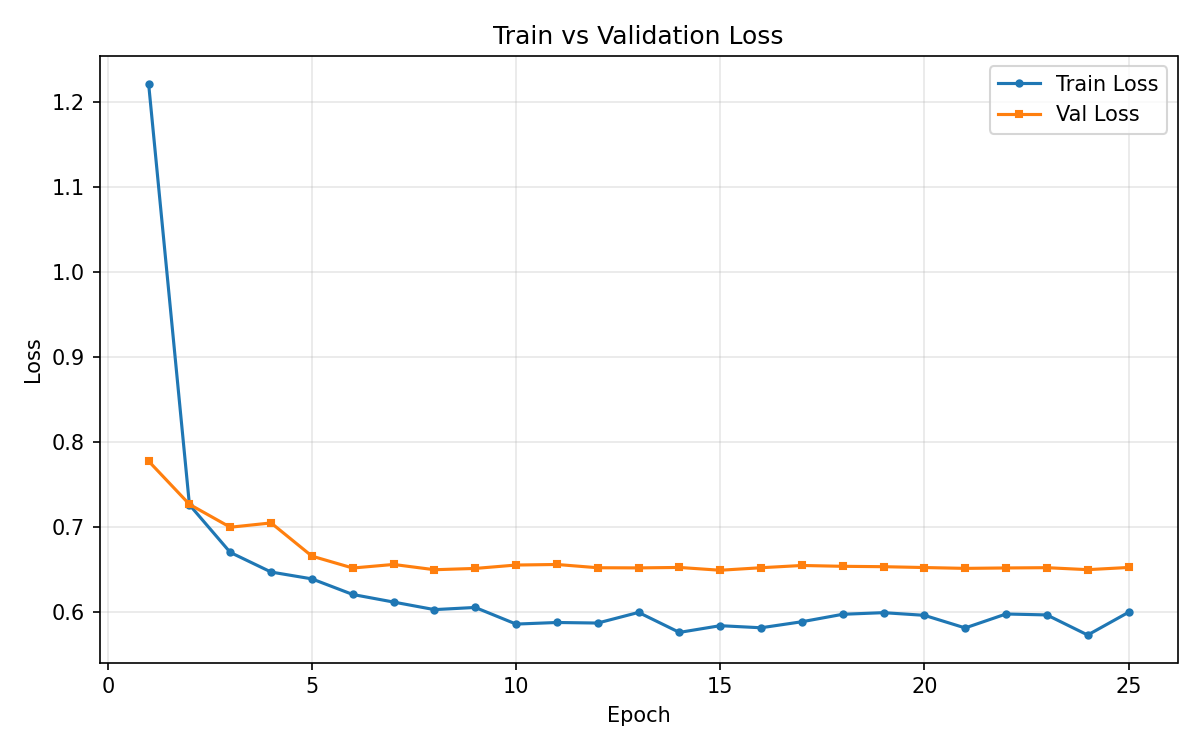

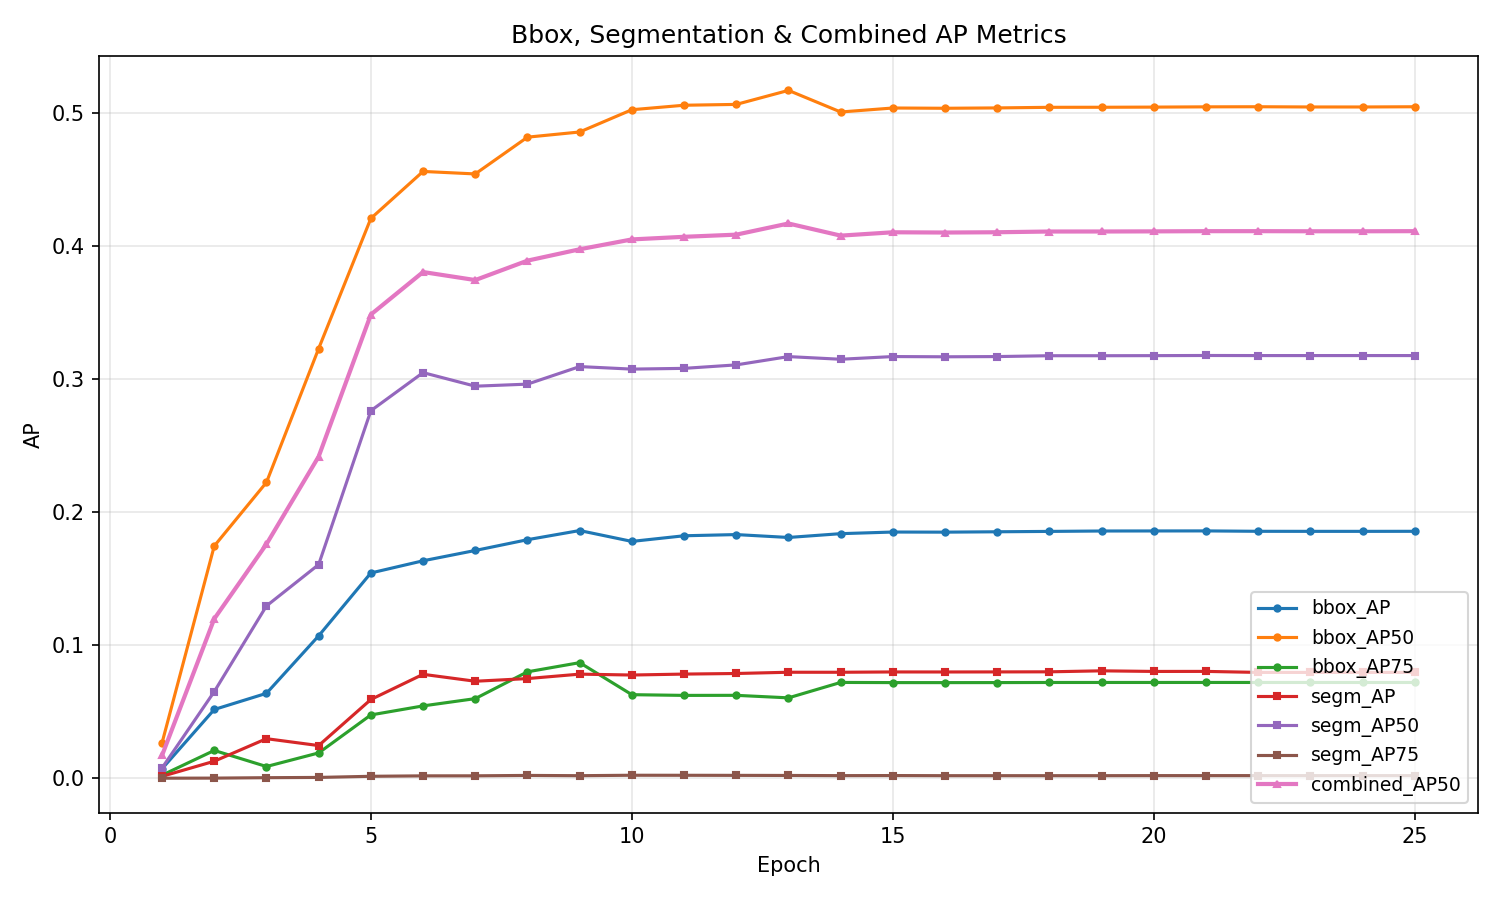

In [5]:
# ============================================================================
# Сохранение кривых обучения и AP на диск
# ============================================================================

print("Сохранение кривых обучения...")
save_training_curves(
    results["train_losses"],
    results["val_losses"],
    results_dir / "training_curves.png",
)
print(f"  -> {results_dir / 'training_curves.png'}")

print("\nСохранение кривых AP...")
save_ap_curves(
    results["metrics_per_epoch"],
    results_dir,
)
print("  -> ap_curves.png (bbox + segm + combined AP)")

# ============================================================================
# Отображение всех кривых в блокноте
# ============================================================================

display_results_curves(results_dir)

## 5: Качественные предсказания / Отчёты / Итоги


Файл: images/task_163_img_000186_infected.jpg
Площадь раны: 14.95 cm² | Инфекция: Infected | Уверенность: 0.88


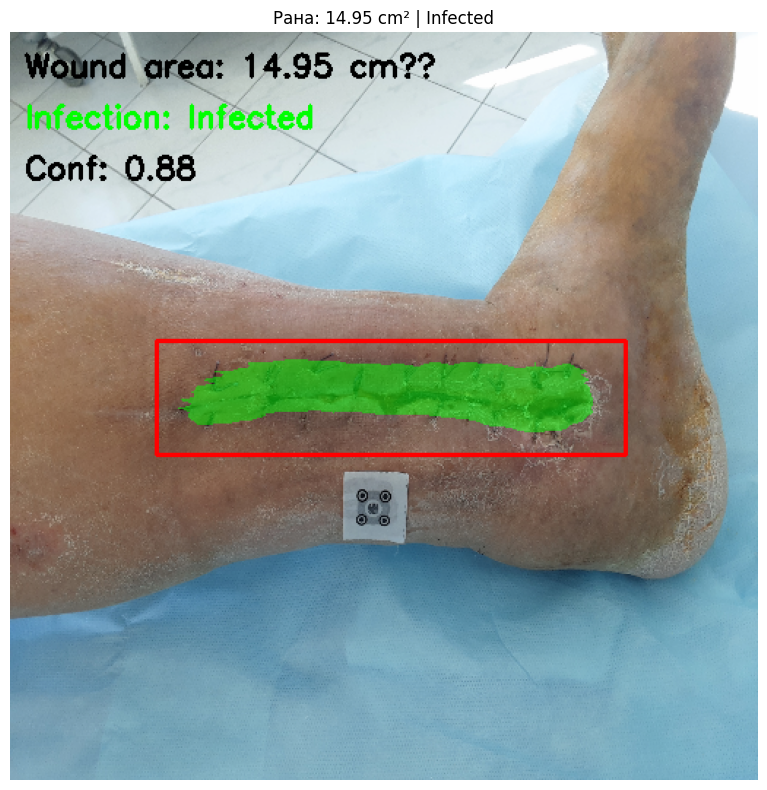


Результаты:
----------------------------------------
Обнаружения: 17
Площадь раны: 15.523668639053254 см²
Инфекция: Infected


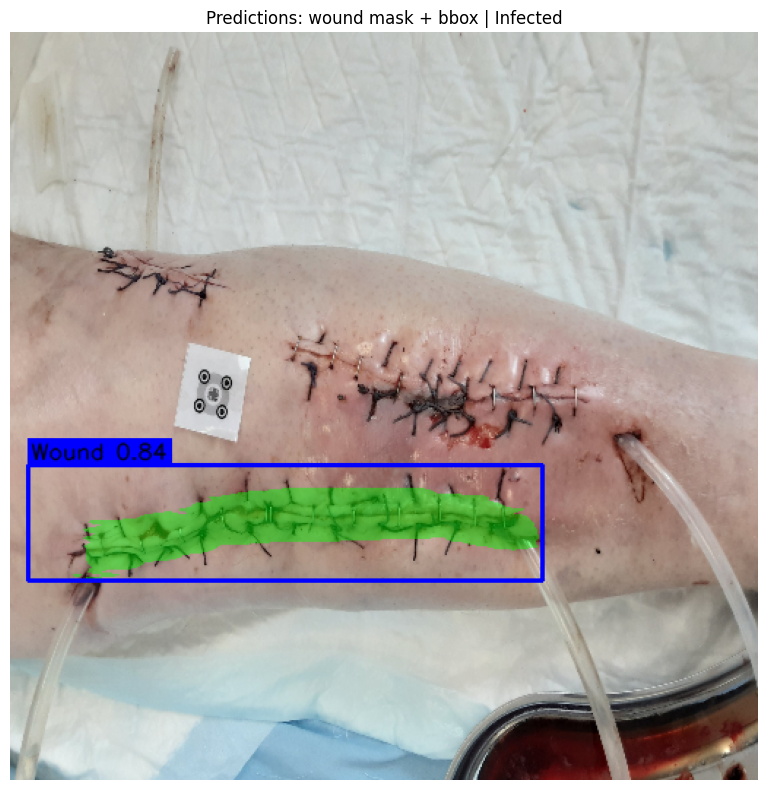

Сохранение качественных предсказаний...
  -> 8 изображений сохранено в E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\results\predictions


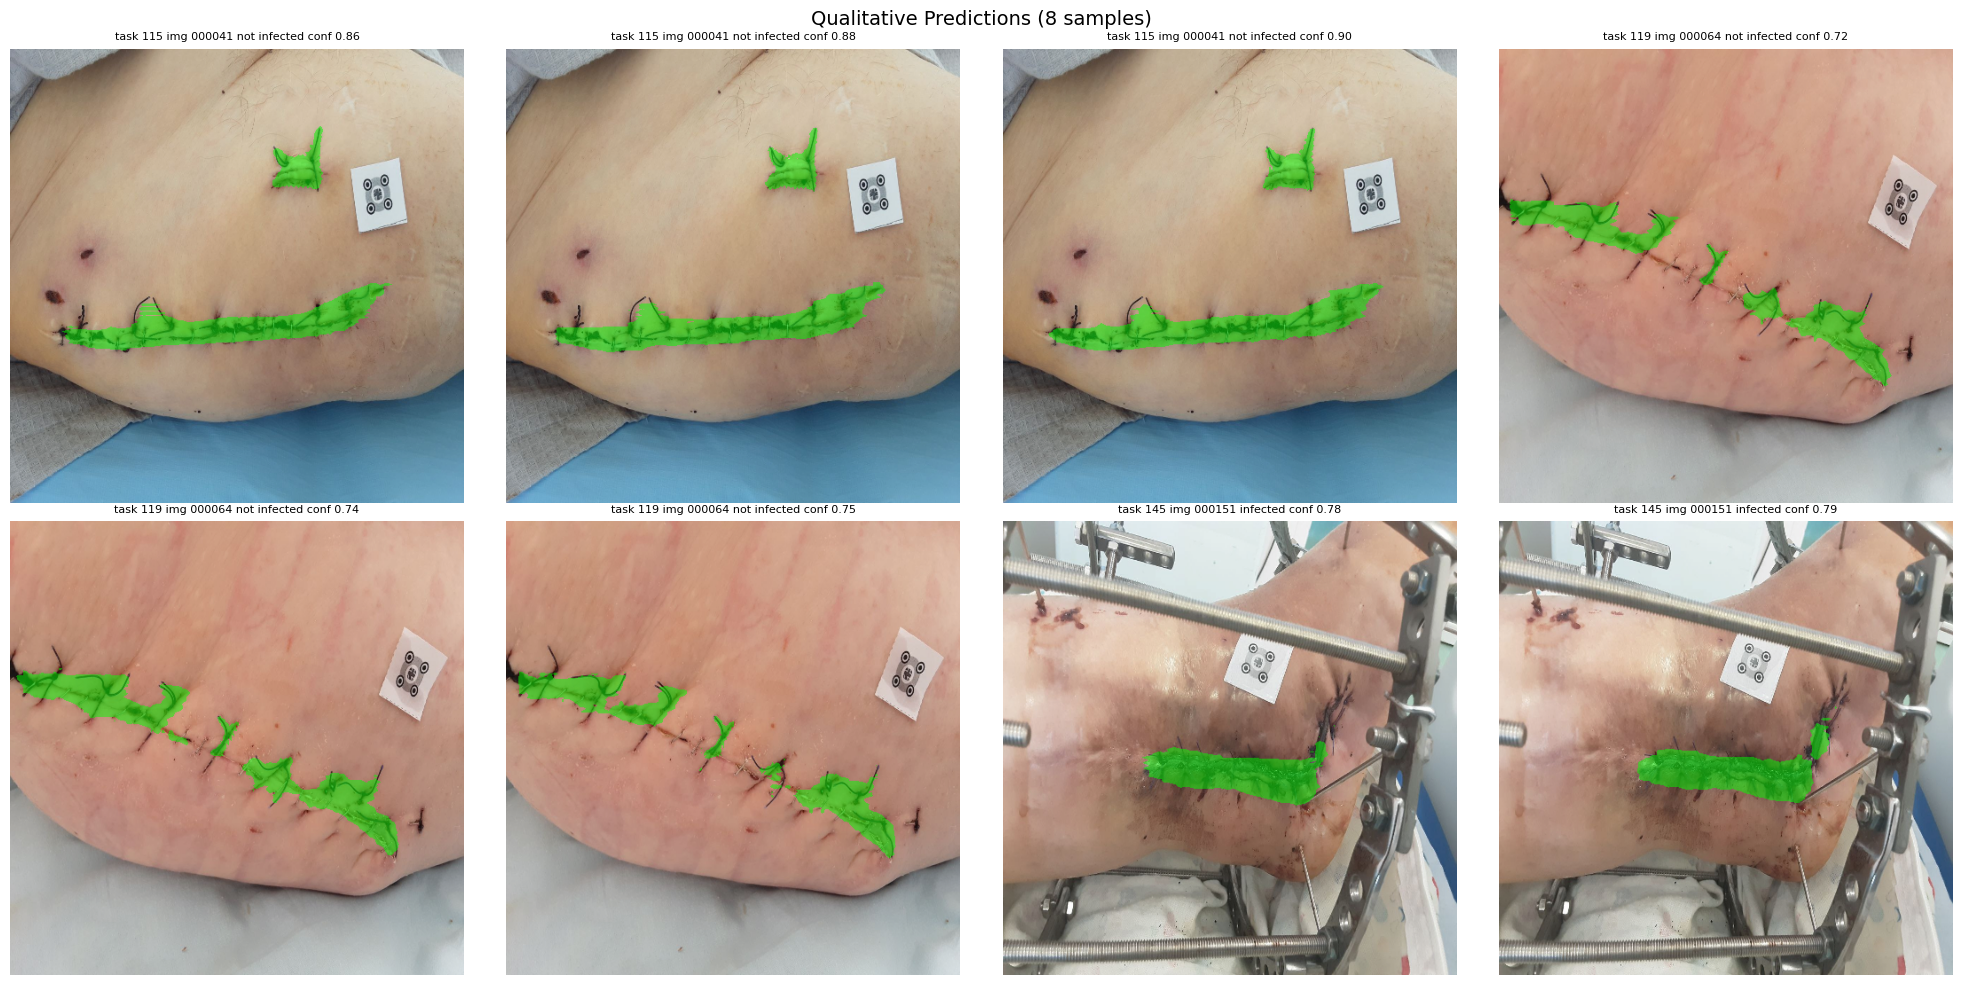


Генерация отчётов только по ранам...
  → Reports saved: E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\reports
  -> E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\reports\wound_only_training_report.md
  -> E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\reports\review_summary_for_chatgpt.md

БАЗОВЫЙ ВАРИАНТ ТОЛЬКО РАН — ИТОГОВАЯ СВОДКА
  Лучший combined_AP50 : 0.4171
  Лучший bbox_AP50     : 0.5171
  Лучший segm_AP50     : 0.3170
  Лучшая эпоха         : 13
  Время обучения       : 3206.9с (53.4 мин)

Test set metrics:
    bbox_AP: 0.1521
    bbox_AP50: 0.3981
    bbox_AP75: 0.0625
    segm_AP: 0.0575
    segm_AP50: 0.2170
    segm_AP75: 0.0076
    combined_AP50: 0.3076

Output locations:
  Checkpoints : E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\checkpoints
  Results     : E:\GitHub\Wound-infection-detection-model\experiments\maskrcnn\results
  Reports     : E:\GitHub\Wound-infection-detection-model\experiments\maskrc

In [6]:
# ============================================================================
# 5.1a Один снимок: площадь раны, ограничивающая рамка, статус инфекции
# ============================================================================

SAMPLE_IDX = 0
img_result, pred_info = predict_single_image(
    model, test_loader, device,
    sample_index=SAMPLE_IDX,
    conf_thresh=CONFIG.get("conf_thresh_qualitative", 0.5),
)
print(f"Файл: {pred_info['file_name']}")
area_str = f"{pred_info['wound_area_cm2']} cm²" if pred_info.get('wound_area_cm2') else f"{pred_info['wound_area_px']} px"
print(f"Площадь раны: {area_str} | Инфекция: {pred_info['infection']} | Уверенность: {pred_info['confidence']:.2f}")

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
ax.set_title(f"Рана: {area_str} | {pred_info['infection']}")
ax.axis("off")
plt.tight_layout()
plt.show()

# ============================================================================
# 5.1b Предсказание по пути к изображению (рамка, площадь, визуализация)
# ============================================================================

# Измените путь к изображению для предсказания (относительно data_root)
image_path = "images/task_172_img_000211_infected.jpg"
CONF_THRESHOLD = 0.3
data_root = Path(CONFIG["data_root"])

result, predictions = predict_image(
    image_path, model, device,
    data_root=data_root,
    image_size=tuple(CONFIG["image_size"]),
    conf_threshold=CONF_THRESHOLD,
    marker_class_id=None,  # wound-only: no marker for cm²
)

print("\nРезультаты:")
print("-" * 40)
print(f"Обнаружения: {result['num_detections']}")
print(f"Площадь раны: {result['wound_area_cm2']} см²" if result['wound_area_cm2'] else f"Площадь раны: {result['wound_area_px']} px")
print(f"Инфекция: {result['infection_label']}")

# Визуализация (рамка + наложение маски)
vis_img = visualize_prediction(
    image_path, predictions,
    data_root=data_root,
    image_size=tuple(CONFIG["image_size"]),
)
plt.figure(figsize=(10, 8))
plt.imshow(vis_img)
plt.title(f"Predictions: wound mask + bbox | {result['infection_label']}")
plt.axis("off")
plt.tight_layout()
plt.show()

# ============================================================================
# 5.1 Качественные предсказания (из train_model.py)
# ============================================================================

print("Сохранение качественных предсказаний...")
n_saved = save_qualitative_predictions(
    model, test_loader, device,
    results_dir,
    num_samples=CONFIG.get("num_qualitative_samples", 8),
    conf_thresh=CONFIG.get("conf_thresh_qualitative", 0.5),
)
print(f"  -> {n_saved} изображений сохранено в {results_dir / 'predictions'}")

# Отображение предсказаний в блокноте
display_results_predictions(results_dir)

# ============================================================================
# 5.2 Генерация отчётов только по ранам (из train_model.py)
# ============================================================================

print("\nГенерация отчётов только по ранам...")
generate_wound_only_report(
    results=results,
    output_dir=reports_dir,
    test_metrics=results.get("test_metrics"),
)
print(f"  -> {reports_dir / 'wound_only_training_report.md'}")
print(f"  -> {reports_dir / 'review_summary_for_chatgpt.md'}")

# ============================================================================
# 5.3 Итоговая сводка
# ============================================================================

print("\n" + "=" * 60)
print("БАЗОВЫЙ ВАРИАНТ ТОЛЬКО РАН — ИТОГОВАЯ СВОДКА")
print("=" * 60)
print(f"  Лучший combined_AP50 : {results['best_metric']:.4f}")
print(f"  Лучший bbox_AP50     : {results['best_bbox_AP50']:.4f}")
print(f"  Лучший segm_AP50     : {results['best_segm_AP50']:.4f}")
print(f"  Лучшая эпоха         : {results['best_epoch']}")
print(f"  Время обучения       : {results['training_time']:.1f}с ({results['training_time']/60:.1f} мин)")
if results.get("test_metrics"):
    print()
    print("Test set metrics:")
    for k, v in results["test_metrics"].items():
        if isinstance(v, (int, float)):
            print(f"    {k}: {v:.4f}")
print()
print("Output locations:")
print(f"  Checkpoints : {output_dir}")
print(f"  Results     : {results_dir}")
print(f"  Reports     : {reports_dir}")
print("=" * 60)


## 6: Обзор — Отображение сохранённых кривых и предсказаний

Run this cell independently to view results from a previous training run without re-training.


СВОДКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ

Лучшая валидация (эпоха 13):
  combined_AP50 : 0.4171
  bbox_AP50     : 0.5171
  segm_AP50     : 0.3170

Тестовый набор:
  bbox_AP: 0.1521
  bbox_AP50: 0.3981
  bbox_AP75: 0.0625
  segm_AP: 0.0575
  segm_AP50: 0.2170
  segm_AP75: 0.0076
  combined_AP50: 0.3076


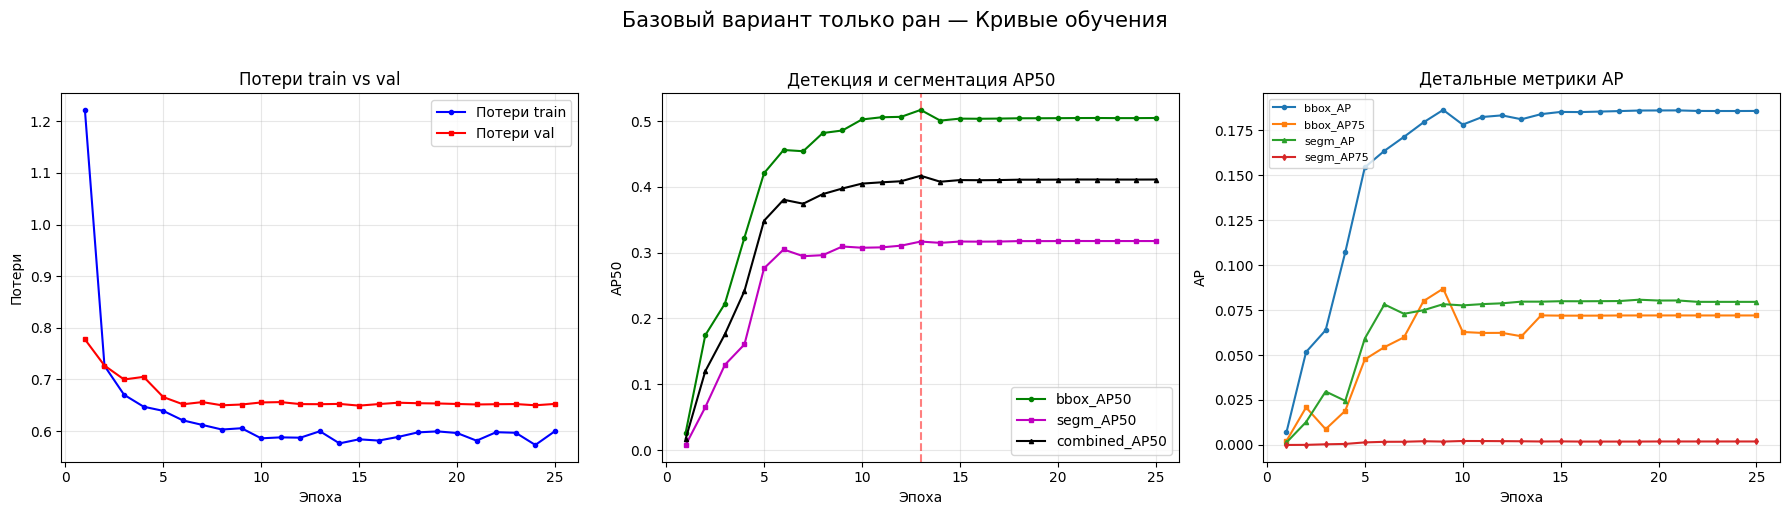


Всего эпох обучено: 25
Финальные потери train: 0.5997
Финальные потери val: 0.6525

СОХРАНЁННЫЕ ИЗОБРАЖЕНИЯ КРИВЫХ


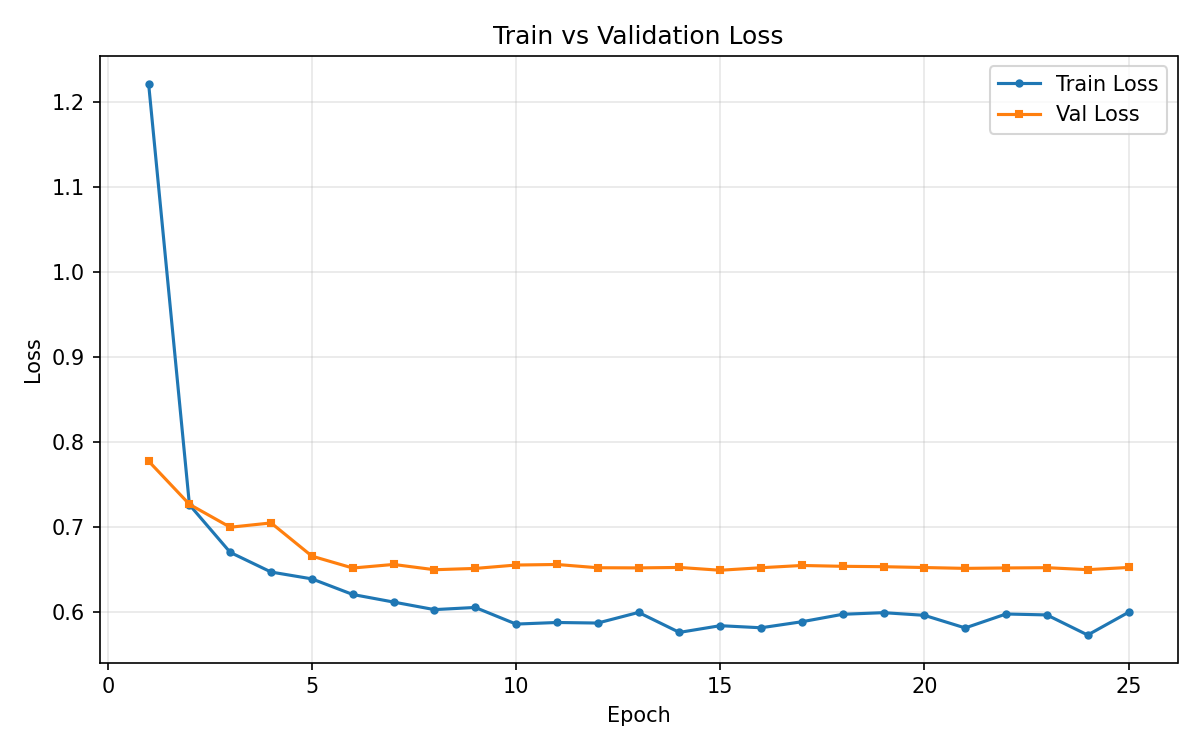

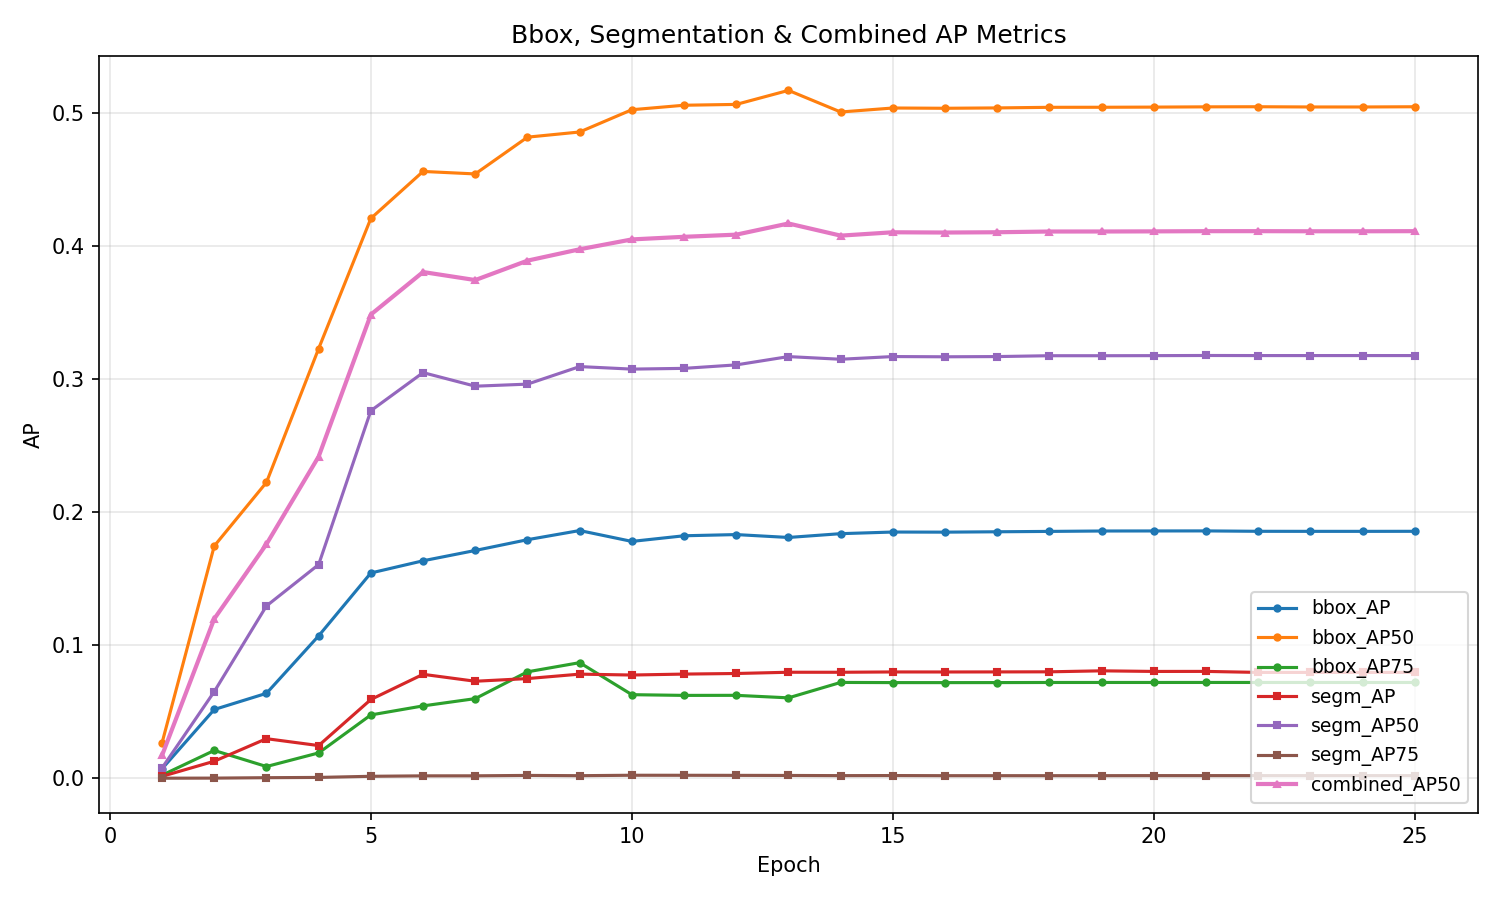


КАЧЕСТВЕННЫЕ ПРЕДСКАЗАНИЯ


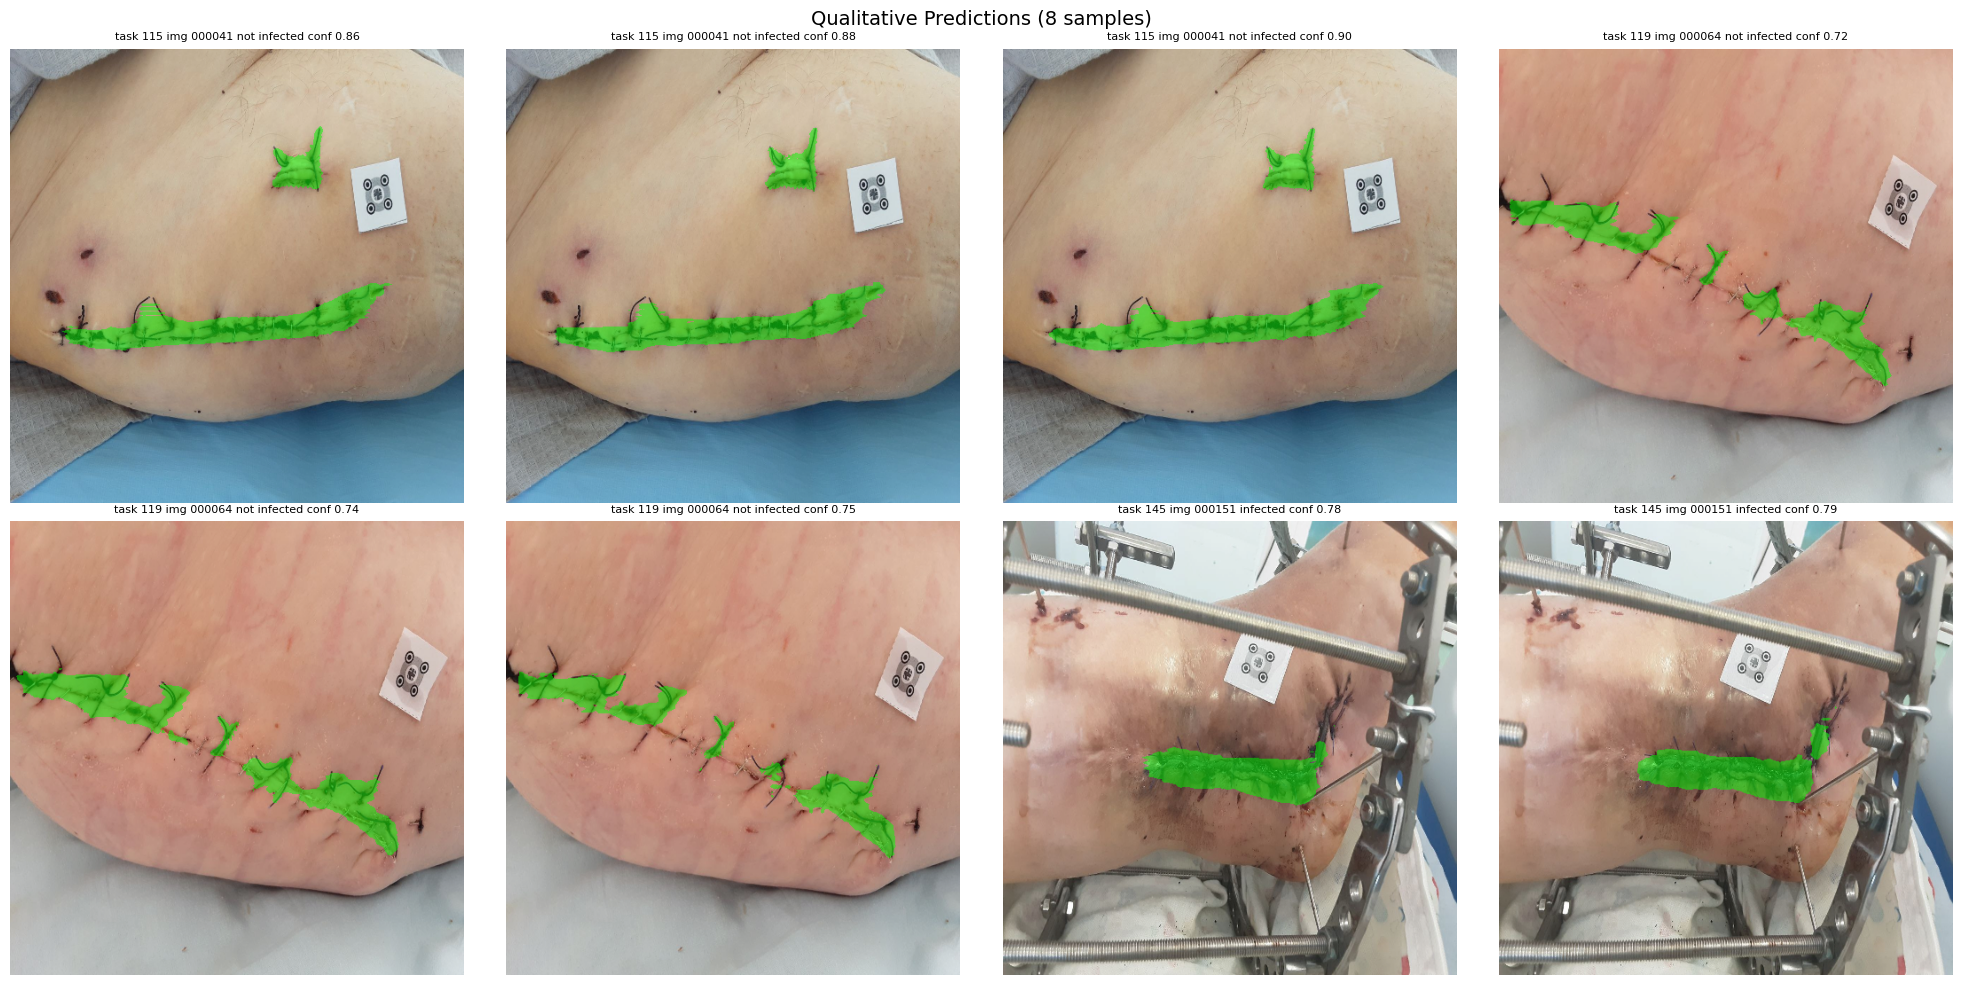


ОТЧЁТ ОБ ОБУЧЕНИИ ТОЛЬКО РАН (предпросмотр)


# Wound-Only Segmentation Training Report

**Generated:** 2026-03-17 09:57:54

## Purpose

Single class: wound. Dataset: wound_focus_clean.

## Dataset

Train: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\train_wound_only.json
Val: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\val_wound_only.json
Test: E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\test_wound_only.json

## Model

Mask R-CNN ResNet-50-FPN, num_classes=2, image_size=(512, 512)

## Sizes

Train: 257, Val: 57, Test: 55

## Best Metrics

Best epoch: 13
combined_AP50: 0.4171
bbox_AP50: 0.5171
segm_AP50: 0.3170

Training time: 3206.89s

## Test Metrics

- bbox_AP: 0.1521
- bbox_AP50: 0.3981
- bbox_AP75: 0.0625
- segm_AP: 0.0575
- segm_AP50: 0.2170
- segm_AP75: 0.0076
- combined_AP50: 0.3076

See results/predictions/ for qualitative outputs.



In [7]:
%matplotlib inline
import json
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

SCRIPT_DIR = Path.cwd().resolve()
sys.path.insert(0, str(SCRIPT_DIR))
from train_model import display_results_curves, display_results_predictions

RESULTS_DIR = SCRIPT_DIR / "results"
REPORTS_DIR = SCRIPT_DIR / "reports"
CHECKPOINTS_DIR = SCRIPT_DIR / "checkpoints"

# ============================================================================
# 6.1 Сводка метрик обучения
# ============================================================================

metrics_file = RESULTS_DIR / "metrics_summary.json"
if metrics_file.exists():
    with open(metrics_file, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    print("=" * 60)
    print("СВОДКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ")
    print("=" * 60)

    best = metrics.get("best_validation", {})
    print(f"\nЛучшая валидация (эпоха {best.get('best_epoch', '?')}):")
    print(f"  combined_AP50 : {best.get('combined_AP50', 0):.4f}")
    print(f"  bbox_AP50     : {best.get('bbox_AP50', 0):.4f}")
    print(f"  segm_AP50     : {best.get('segm_AP50', 0):.4f}")

    test = metrics.get("test", {})
    if test:
        print(f"\nТестовый набор:")
        for k, v in test.items():
            if isinstance(v, (int, float)):
                print(f"  {k}: {v:.4f}")
    print("=" * 60)
else:
    print("[ВНИМАНИЕ] Файл metrics_summary.json не найден. Сначала выполните обучение.")

# ============================================================================
# 6.2 История обучения (потери по эпохам)
# ============================================================================

history_file = CHECKPOINTS_DIR / "training_history.json"
if history_file.exists():
    with open(history_file, "r", encoding="utf-8") as f:
        history = json.load(f)

    train_losses = history.get("train_losses", [])
    val_losses = history.get("val_losses", [])
    metrics_per_epoch = history.get("metrics_per_epoch", [])

    if train_losses:
        epochs = range(1, len(train_losses) + 1)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Loss curves
        axes[0].plot(epochs, train_losses, "b-o", markersize=3, label="Потери train")
        axes[0].plot(epochs, val_losses, "r-s", markersize=3, label="Потери val")
        axes[0].set_xlabel("Эпоха")
        axes[0].set_ylabel("Потери")
        axes[0].set_title("Потери train vs val")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # AP50 curves
        if metrics_per_epoch:
            bbox_ap50 = [m.get("bbox_AP50", 0) for m in metrics_per_epoch]
            segm_ap50 = [m.get("segm_AP50", 0) for m in metrics_per_epoch]
            combined = [m.get("combined_AP50", 0) for m in metrics_per_epoch]
            ep = range(1, len(metrics_per_epoch) + 1)

            axes[1].plot(ep, bbox_ap50, "g-o", markersize=3, label="bbox_AP50")
            axes[1].plot(ep, segm_ap50, "m-s", markersize=3, label="segm_AP50")
            axes[1].plot(ep, combined, "k-^", markersize=3, label="combined_AP50")
            axes[1].set_xlabel("Эпоха")
            axes[1].set_ylabel("AP50")
            axes[1].set_title("Детекция и сегментация AP50")
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            # Highlight best epoch
            best_idx = np.argmax(combined)
            axes[1].axvline(x=best_idx + 1, color="red", linestyle="--", alpha=0.5,
                            label=f"Лучшая эпоха {best_idx+1}")

            # Detailed AP breakdown
            bbox_ap = [m.get("bbox_AP", 0) for m in metrics_per_epoch]
            segm_ap = [m.get("segm_AP", 0) for m in metrics_per_epoch]
            bbox_ap75 = [m.get("bbox_AP75", 0) for m in metrics_per_epoch]
            segm_ap75 = [m.get("segm_AP75", 0) for m in metrics_per_epoch]

            axes[2].plot(ep, bbox_ap, "-o", markersize=3, label="bbox_AP")
            axes[2].plot(ep, bbox_ap75, "-s", markersize=3, label="bbox_AP75")
            axes[2].plot(ep, segm_ap, "-^", markersize=3, label="segm_AP")
            axes[2].plot(ep, segm_ap75, "-d", markersize=3, label="segm_AP75")
            axes[2].set_xlabel("Эпоха")
            axes[2].set_ylabel("AP")
            axes[2].set_title("Детальные метрики AP")
            axes[2].legend(fontsize=8)
            axes[2].grid(True, alpha=0.3)

        fig.suptitle("Базовый вариант только ран — Кривые обучения", fontsize=15, y=1.02)
        fig.tight_layout()
        plt.show()

        print(f"\nВсего эпох обучено: {len(train_losses)}")
        print(f"Финальные потери train: {train_losses[-1]:.4f}")
        print(f"Финальные потери val: {val_losses[-1]:.4f}")
else:
    print("[ВНИМАНИЕ] Файл training_history.json не найден.")

# ============================================================================
# 6.3 Сохранённые изображения кривых
# ============================================================================

print("\n" + "=" * 60)
print("СОХРАНЁННЫЕ ИЗОБРАЖЕНИЯ КРИВЫХ")
print("=" * 60)
display_results_curves(RESULTS_DIR)

# ============================================================================
# 6.4 Качественные предсказания
# ============================================================================

print("\n" + "=" * 60)
print("КАЧЕСТВЕННЫЕ ПРЕДСКАЗАНИЯ")
print("=" * 60)
display_results_predictions(RESULTS_DIR)

# ============================================================================
# 6.5 Предпросмотр отчёта
# ============================================================================

report_file = REPORTS_DIR / "wound_only_training_report.md"
if report_file.exists():
    print("\n" + "=" * 60)
    print("ОТЧЁТ ОБ ОБУЧЕНИИ ТОЛЬКО РАН (предпросмотр)")
    print("=" * 60)
    text = report_file.read_text(encoding="utf-8")
    display(Markdown(text))